# CNN for Insect Classification

Team Members: Katie Luce, Durge Kumar, Richa Tiwari, Jesus Dani Martinez

Brief Description of our Topic:

Our team plans on using Convolutional Neural Networks (CNN) to conduct image classification of insects using the “Kaggle: Insect Classification Dataset”.  CNNs are deep learning models designed for image analysis to identify and classify insects from pictures. This model will learn visual patterns such as wing shape, body color, leg structure, antennae and other features to distinguish between insect images that look the same to a human eye. This is particularly useful because manual insect classification can be time consuming and error prone. In addition, the CNNs is made up of convolutional layers that filter inputs and learn the hierarchical representations of images to capture both the simple and complex patterns. The convolution operation involves combining the feature map and convolution kernel (filter) to create a feature map. Furthermore, the filters are modified continuously based on the learned parameters to get the most important features. Overall, the Convolutional Neural Networks adjust automatically and find the best features to identify the insects correctly. 

Expected Outcome:

The goal of this project is to develop and train a Convolutional Neural Network (CNN) model for insect image classification. The proposed model is intended to accurately classify insect images by learning and identifying important visual features such as shape, color, and structural patterns and using subtraction methods in image recognition to then make a more accurate prediction. In addition to building a reliable classification system, the project aims to achieve a high level of performance in terms of accuracy, precision, and recall as well as learning rate. To ensure the model’s effectiveness, its performance will be evaluated using metrics such as the accuracy score and confusion matrix, which will help measure how well the model distinguishes between different insect classes. On top of using pooling methods to have a convoluted image and thus extract relevant information that helps predict and classify any given image.
    
Our deliverables will include code of our exploratory analysis and model, visualizations used to better understand our data and methods, a written report, and a presentation.

## Part 1: Research and Data Preparation

### Helpful Resources for CNN in Python:



Link: https://www.kaggle.com/code/vencerlanz09/insect-classification-using-cnn-mobilenetv3

Summary: Created an image classification model that detects insects of different classes using Transfer Learning. Uses Python for preprocessing, splitting the data into Training, Validation, and Testing data, to train and test the deep learning CNN model and parameters were fine-tuned with the validation data. 

Thoughts on how we can use this for our project: There is a ton of code here that will be helpful for us. We can split our dataset into 3 subsets like they did and use them to train, fine-tune, and test our data. 

Link: https://betanet.net/view-post/cnn-classification-in-python-a-8833#google_vignette

Summary: This article breaks down CNN in Python into 5 steps, including some helpful code. This method uses the TensorFlow library to build their CNN classifier.

Thoughts on how we can use this for our project: This can be used as a simple tutorial to using TensorFlow for our CNN project.

Link: https://www.datacamp.com/tutorial/pytorch-cnn-tutorial

Summary: This article goes into detail about where CNN originated, what it is, and how it can be applied to real-life case studies. It then gives a step-by-step breakdown of how to implement CNN with PyTorch and how to improve on model performance.

Thoughts on how we can use this for our project: This can be used for our paper to contextualize what CNN is, and can be followed for using PyTorch to build our CNN model.


### Previous research using CNN to classify insects:



- https://ieeexplore.ieee.org/abstract/document/9745134

This study produced a mobile-based decision support software with a deep learning model for insect classification. They also compared the results of multiple deep learning models, SSD MobileNET, YoloV4, and Faster R-CNN Inception V3. They concluded that Faster R-CNN Inception V3 performed the best at classifying and detecting insects at the order level. They also shared training and testing data to Kaggle (Durmas et al., 2022).

- https://www.sciencedirect.com/science/article/pii/S2214317320302067

This study applied machine learning techniques such as artificial neural networks, support vector machine, k-nearest neighbors, naive bayes, and convolutional neural networks and presented an insect pest detection algorithm. They applied 9-fold cross-validation to improve model performance. The results of their classification models are used to recognize crop insects at an early stage to improve crop quality (Thenmozhi et al., 2021).

- https://ieeexplore.ieee.org/abstract/document/8581103?casa_token=agYWfF_Zuj8AAAAA:spQ-0HTC0R8gVdTDB2PfzoySlQMoVFbRaqHn6O06j38LrYRufoCJfDNzW-7BElKTOLTm3hlHlB82-A

This study developed a classification application that can be used in mobile phones for classifying insects. 30 insect species were selected for experiments; their system was able to average a classification accuracy of 94% at a classification speed of 0.03 seconds (Suchang et al., 2018).

### How Our Project Fills the Research Gap:

In [1]:
# dani
# also what dataset did u find?

### About the Dataset We Chose:

In [2]:
# let's make sure we're on the same page about the dataset we're using before completing this part
# richa

### Read in Libraries

In [3]:
!pip install tensorflow

In [4]:
%pip install openml

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Import Data Science Libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import itertools
import random
import tensorflow as tf

# Import visualization libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
#import cv2

from tensorflow.keras import layers

# System libraries
from pathlib import Path
import os.path

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

### Load Data

In [6]:
import openml

# Download the dataset and ALL associated files (the images)
dataset = openml.datasets.get_dataset(44276, download_data=True, download_all_files=True)

# This will tell you where the images are stored on your computer
#print(f"Images are saved in: {openml.config.cache_directory}")
print("OpenML cache directory:", openml.config.get_cache_directory())

C:\Users\rajku\AppData\Local\Temp\ipykernel_22036\2094464582.py:4: FutureWarning: ``download_all_files`` is experimental and is likely to break with new releases.
  dataset = openml.datasets.get_dataset(44276, download_data=True, download_all_files=True)


OpenML cache directory: C:\Users\rajku\.openml\org\openml\www


In [7]:
%pip install ibis-framework

Note: you may need to restart the kernel to use updated packages.


In [8]:
import os
import ibis

import altair as alt
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from PIL import Image


using the micro dataset found at this link: https://www.openml.org/search?type=data&sort=runs&id=44276&status=active

**DID NOT RUN THE with open('dataset_ only works for local')...**-DK

### Exploratory Analysis

In [9]:
#import re
#import pandas as pd
#import io

# Read the messy file
#with open('dataset_', 'r', encoding='utf-8') as f:
    #content = f.read()

# There are some things messing up the formatting of the data when I read in the file, so I do this:
# Remove the tags [cite: 1, 2, 3]
# Also remove newlines that appear immediately after a source tag 
# to fix those broken category names [cite: 2, 6, 11]
#clean_content = re.sub(r'\\s*', '', content)

# Now read the cleaned string into Pandas
# We still skip the ARFF header lines
#data_start_idx = clean_content.find('@DATA') + 5
#df = pd.read_csv(io.StringIO(clean_content[data_start_idx:]), 
                 #header=None, 
                 #names=['FILE_NAME', 'CATEGORY', 'SUPER_CATEGORY'],
                 #quotechar="'")

#print(df.head())

**RAN THIS-- worked!-DK**

In [10]:
X, y, categorical_indicator, attribute_names = dataset.get_data()

import pandas as pd
df = pd.DataFrame(X, columns=attribute_names)

print(df.head())

                                  FILE_NAME  \
0                         1554709269094.jpg   
1  56ad14c5-fe8b-47c5-88ba-9736ab42bfa6.JPG   
2                         1446228668427.jpg   
3               13123632011312372811318.jpg   
4                1336509140133650914090.jpg   

                                            CATEGORY SUPER_CATEGORY  
0                                           Muscidae      Muscoidea  
1    Les Ulidides métalliques (Physiphora et autres)      Ulidiidae  
2  Les Syrphes Syrphus et autres (Syrphus, Dasysy...      Syrphidae  
3                                          Sphecidae        Apoidea  
4                        Les Géomètres (Geometridae)    Geometridae  


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   FILE_NAME       800 non-null    object
 1   CATEGORY        800 non-null    object
 2   SUPER_CATEGORY  800 non-null    object
dtypes: object(3)
memory usage: 18.9+ KB


We have 800 rows of 3 columns; the file name, category and super category.

In [12]:
df["CATEGORY"].value_counts()

CATEGORY
Muscidae                                                          40
Les Ulidides métalliques (Physiphora et autres)                   40
Les Syrphes Syrphus et autres (Syrphus, Dasysyrphus et autres)    40
Sphecidae                                                         40
Les Géomètres (Geometridae)                                       40
Tenebrionidae                                                     40
Colletidae                                                        40
Les Adèles unies (plusieurs Adelidae)                             40
Les Epeires concombre (Araniella)                                 40
Dasytidae                                                         40
Pompilidae                                                        40
Erebidae                                                          40
Le Moro-sphinx (Macroglossum stellatarum)                         40
Andrenidae                                                        40
Oedemeridae              

In [13]:
df["SUPER_CATEGORY"].value_counts()

SUPER_CATEGORY
Syrphidae         160
Apoidea           120
Tenebrionoidea     80
Muscoidea          40
Ulidiidae          40
Geometridae        40
Adelidae           40
Araneidae          40
Cleroidea          40
Vespoidea          40
Noctuoidea         40
Sphingidae         40
Chloropidae        40
Stratiomyidae      40
Name: count, dtype: int64

In [14]:
import openml
import os
import matplotlib.pyplot as plt
from PIL import Image

# Find image folder automatically
cache_dir = openml.config.get_cache_directory()

image_folder_path = None
for root, dirs, files in os.walk(cache_dir):
    if any(f.endswith(".jpg") for f in files):
        image_folder_path = root
        break

print("Using image folder:", image_folder_path)

Using image folder: C:\Users\rajku\.openml\org\openml\www\datasets\44276\INS_Micro\images


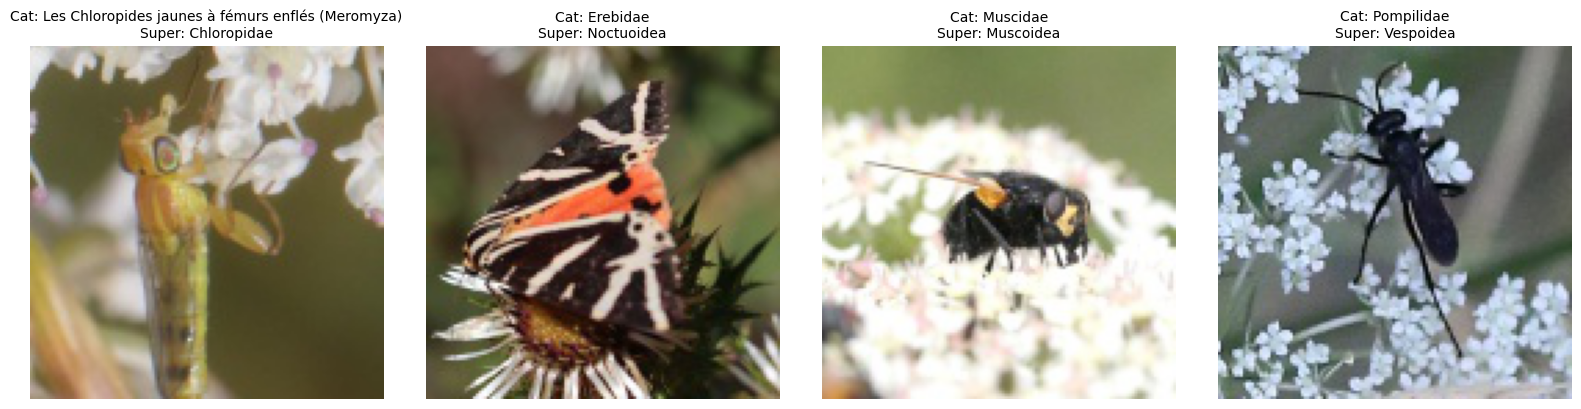

In [15]:
#Showing Images
def show_random_images(df, folder_path, num_to_show=4):
    # Select random samples
    samples = df.sample(num_to_show)
    
    # Create the plot grid
    plt.figure(figsize=(16, 4))
    
    for i, (idx, row) in enumerate(samples.iterrows()):
        # Construct the full path: folder + filename from dataset
        img_filename = row['FILE_NAME']
        img_full_path = os.path.join(folder_path, img_filename)
        
        try:
            # Open and display the image
            img = Image.open(img_full_path)
            plt.subplot(1, num_to_show, i + 1)
            plt.imshow(img)
            
            # Use the CATEGORY and SUPER_CATEGORY as titles 
            title = f"Cat: {row['CATEGORY']}\nSuper: {row['SUPER_CATEGORY']}"
            plt.title(title, fontsize=10)
            plt.axis('off') # Hide the x/y axis numbers
            
        except FileNotFoundError:
            plt.subplot(1, num_to_show, i + 1)
            plt.text(0.5, 0.5, f"Image Not Found:\n{img_filename}", 
                     ha='center', va='center')
            plt.axis('off')

    plt.tight_layout()
    plt.show()


#Run It!
show_random_images(df, image_folder_path)

**Visualization describing images count per category**

   SUPER_CATEGORY  COUNT
0       Syrphidae    160
1         Apoidea    120
2  Tenebrionoidea     80
3       Muscoidea     40
4       Ulidiidae     40


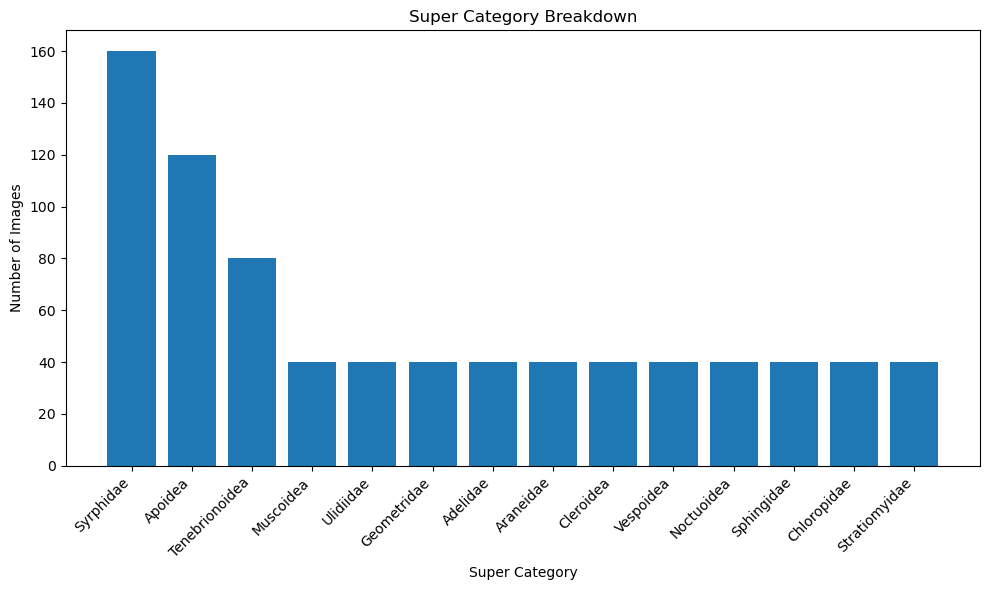

In [16]:
super_counts = df['SUPER_CATEGORY'].value_counts().reset_index()
super_counts.columns = ['SUPER_CATEGORY', 'COUNT']

print(super_counts.head())

plt.figure(figsize=(10, 6))
plt.bar(super_counts['SUPER_CATEGORY'], super_counts['COUNT'])
plt.xticks(rotation=45, ha='right')
plt.title('Super Category Breakdown')
plt.xlabel('Super Category')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.show()

**OVERALL MODEL BUILDING**

**-----------------------------------------**

**Step 1: Define SUPER_CATEGORY as target**

In [17]:
print("Unique super categories:", df['SUPER_CATEGORY'].nunique())
print(df['SUPER_CATEGORY'].value_counts().head())

Unique super categories: 14
SUPER_CATEGORY
Syrphidae         160
Apoidea           120
Tenebrionoidea     80
Muscoidea          40
Ulidiidae          40
Name: count, dtype: int64


**Step 2: Clean + prepare dataset**

In [18]:
# Drop missing values
df_clean = df.dropna(subset=['FILE_NAME', 'SUPER_CATEGORY'])

print("Clean dataset shape:", df_clean.shape)

Clean dataset shape: (800, 3)


**Step 3: Preprocess images + encode labels** --- 
load images + 
resize them +
normalize pixels +
encode labels

In [19]:
import numpy as np
from PIL import Image
import os
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 128

X = []
y = []

for _, row in df_clean.iterrows():
    img_path = os.path.join(image_folder_path, row['FILE_NAME'])
    
    try:
        img = Image.open(img_path).convert('RGB')
        img = img.resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img) / 255.0 
        
        X.append(img_array)
        y.append(row['SUPER_CATEGORY'])
        
    except:
        continue  

X = np.array(X)
y = np.array(y)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)
print("Classes:", le.classes_)

Images shape: (800, 128, 128, 3)
Labels shape: (800,)
Classes: ['Adelidae' 'Apoidea' 'Araneidae' 'Chloropidae' 'Cleroidea' 'Geometridae'
 'Muscoidea' 'Noctuoidea' 'Sphingidae' 'Stratiomyidae' 'Syrphidae'
 'Tenebrionoidea' 'Ulidiidae' 'Vespoidea']


**Step 4: Train / Validation / Test split**

In [20]:
from sklearn.model_selection import train_test_split

# First split: train + temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Second split: validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5 random_state=42, stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (640, 128, 128, 3)
Validation: (112, 128, 128, 3)
Test: (48, 128, 128, 3)


**Step 5: Build CNN Model**

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_classes = len(le.classes_)

cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

cnn_model.summary()

C:\Users\rajku\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 14)                  │           1,806 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,306,446 (12.61 MB)

 Trainable params: 3,306,446 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

**Step 6: Compile model**

In [22]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

**Step 7: Train model**

In [23]:
from tensorflow.keras.utils import to_categorical

num_classes = len(le.classes_)

y_train = to_categorical(y_train, num_classes=num_classes)
y_val   = to_categorical(y_val, num_classes=num_classes)
y_test  = to_categorical(y_test, num_classes=num_classes)

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)
print("Number of classes:", len(le.classes_))

X_train shape: (640, 128, 128, 3)
y_train shape: (640, 14)
X_val shape: (112, 128, 128, 3)
y_val shape: (112, 14)
Number of classes: 14


**Step 9: Evaluate Model**

In [25]:
test_loss, test_acc = cnn_model.evaluate(X_test, y_test)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.0208 - loss: 2.6468     
Test Loss: 2.646848440170288
Test Accuracy: 0.02083333395421505


**PERFOMING VERY POORLY** 

**NEXT STEPS ADD VISUALIZATIONS CHARTS/CONFUSION MATRIX + FIND OUT WHY? (LOW IMAGES IN DATASET?)**